# Nettoyage de données — Ventes de restaurants

**Dataset** : 17 534 transactions avec erreurs et incohérences réalistes  
**Objectif** : Préparer les données pour l'analyse et le machine learning

---

## 1. Chargement et exploration initiale

### 1.1 Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


### 1.2 Chargement des données

In [2]:
rep_courant = os.getcwd()
df = pd.read_csv(rep_courant + "/restaurant_data.csv")
df.head(10)

,Order ID,Customer ID,Category,Item,Price,Quantity,Order Total,Order Date,Payment Method
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1.0,3.0,2023-12-21,Credit Card
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,ORD_630508,CUST_075,Drinks,NaN,NaN,2.0,5.0,2022-08-09,Credit Card
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash
5,ORD_381680,CUST_031,Main Dishes,Salmon,18.0,5.0,90.0,2022-07-20,Digital Wallet
6,ORD_270994,CUST_071,Side Dishes,Garlic Bread,4.0,5.0,20.0,2022-08-19,Credit Card
7,ORD_146656,CUST_077,Main Dishes,NaN,15.0,3.0,45.0,2023-02-15,Cash
8,ORD_428611,CUST_083,Desserts,NaN,6.0,2.0,12.0,2023-12-16,Cash
9,ORD_743636,CUST_085,Main Dishes,Vegetarian Platter,14.0,5.0,70.0,2022-08-07,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17534 entries, 0 to 17533
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        17534 non-null  object 
 1   Customer ID     17534 non-null  object 
 2   Category        17534 non-null  object 
 3   Item            15776 non-null  object 
 4   Price           16658 non-null  float64
 5   Quantity        17104 non-null  float64
 6   Order Total     17104 non-null  float64
 7   Order Date      17534 non-null  object 
 8   Payment Method  16452 non-null  object 
dtypes: float64(3), object(6)
memory usage: 1.2+ MB


**Observations :**
- Variables de type `object` (catégorielles) et `float`
- Valeurs nulles dans : `Item`, `Price`, `Quantity`, `Order Total`, `Payment Method`
- `Order Date` est en string → à convertir en datetime
- `Quantity` est en float alors que ce sont des entiers → à corriger

## 2. Renommage des colonnes

In [5]:
# Conversion de la date avant renommage
df["Order Date"] = pd.to_datetime(df["Order Date"])

df = df.rename(columns={
    "Order ID":       "ID Commande",
    "Customer ID":    "ID Client",
    "Category":       "Categorie",
    "Item":           "Type",
    "Price":          "Prix",
    "Quantity":       "Quantité",
    "Order Total":    "Total Commande",
    "Order Date":     "Date Commande",
    "Payment Method": "Méthode Paiement"
})

# Vérification : aucune colonne anglaise ne doit subsister
cols_en = [c for c in df.columns if c in ["Price","Quantity","Order Total","Order Date","Item"]]
if cols_en:
    df = df.drop(columns=cols_en)
    print(f"Colonnes supprimées : {cols_en}")

df.head()

,ID Commande,ID Client,Categorie,Type,Prix,Quantité,Total Commande,Date Commande,Méthode Paiement
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1.0,3.0,2023-12-21,Credit Card
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,ORD_630508,CUST_075,Drinks,NaN,NaN,2.0,5.0,2022-08-09,Credit Card
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash


## 3. Vérification et suppression des doublons

In [6]:
# Taille avant suppression
n_avant = len(df)

df = df.drop_duplicates()

# Nombre de lignes supprimées
print(f"{n_avant - len(df)} lignes dupliquées supprimées")
print(f"Taille actuelle : {len(df):,} lignes")

0 lignes dupliquées supprimées
Taille actuelle : 17,534 lignes


## 4. Gestion des valeurs manquantes

In [7]:
# Vue d'ensemble avant traitement
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()
print("Pourcentage :")
print((df.isnull().sum() / len(df) * 100).round(2))

Valeurs manquantes par colonne :
ID Commande            0
ID Client              0
Categorie              0
Type                1758
Prix                 876
Quantité             430
Total Commande       430
Date Commande          0
Méthode Paiement    1082
dtype: int64

Pourcentage :
ID Commande          0.00
ID Client            0.00
Categorie            0.00
Type                10.03
Prix                 5.00
Quantité             2.45
Total Commande       2.45
Date Commande        0.00
Méthode Paiement     6.17
dtype: float64


### 4.1 Prix (numérique)

Chaque plat a un prix fixe dans le menu.  
**Stratégie** : imputation par la **médiane du même plat** (plus robuste que la moyenne face aux valeurs extrêmes).  
**Fallback** : si le plat est aussi manquant, on utilise la médiane de la catégorie.

In [8]:
# Étape 1 : imputation par médiane du plat
prix_median = df.groupby("Type", observed=True)["Prix"].transform("median")
df["Prix"] = df["Prix"].fillna(prix_median)

# Étape 2 : fallback par médiane de la catégorie (quand Type est aussi NaN)
prix_cat = df.groupby("Categorie", observed=True)["Prix"].transform("median")
df["Prix"] = df["Prix"].fillna(prix_cat)

print(f"Prix : {df['Prix'].isnull().sum()} valeurs manquantes restantes")

Prix : 0 valeurs manquantes restantes


### 4.2 Quantité (numérique)

Étudions d'abord la distribution pour choisir la bonne stratégie d'imputation.

Quantité
1.0    3380
2.0    3374
3.0    3453
4.0    3418
5.0    3479
Name: count, dtype: int64


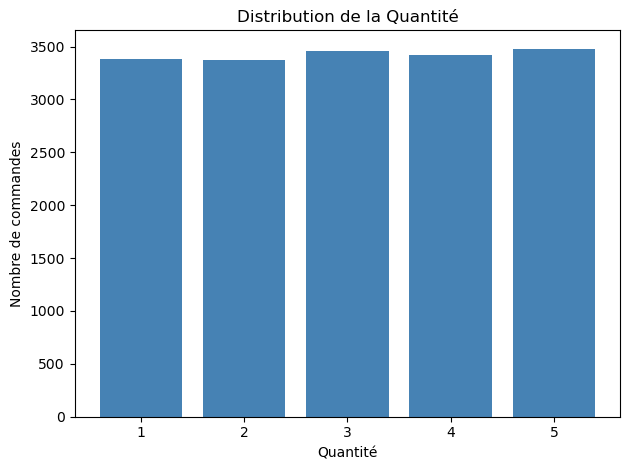

In [9]:
print(df["Quantité"].value_counts().sort_index())

counts = df["Quantité"].value_counts().sort_index()
plt.bar(counts.index, counts.values, color="steelblue")
plt.xticks(counts.index)
plt.xlabel("Quantité")
plt.ylabel("Nombre de commandes")
plt.title("Distribution de la Quantité")
plt.tight_layout()
plt.show()

**Observation** : distribution quasi-uniforme et symétrique (1≈5, 2≈4).  
**Stratégie** : imputation par la **médiane par plat**, avec fallback par catégorie (même logique que le Prix).

In [10]:

quantité_median = df.groupby("Type", observed=True)["Quantité"].transform("median")
df["Quantité"] = df["Quantité"].fillna(quantité_median)


quantité_cat = df.groupby("Categorie", observed=True)["Quantité"].transform("median")
df["Quantité"] = df["Quantité"].fillna(quantité_cat)

print(f"Quantité : {df['Quantité'].isnull().sum()} valeurs manquantes restantes")

Quantité : 0 valeurs manquantes restantes


### 4.3 Total commande (numérique)

Le total découle directement de `Prix × Quantité`.  
**Stratégie** : recalcul systématique — comble les manquants ET garantit la cohérence avec les valeurs existantes.

In [11]:
df["Total Commande"] = df["Prix"] * df["Quantité"]
print(f"Total Commande : {df['Total Commande'].isnull().sum()} valeurs manquantes restantes")
df.head()

Total Commande : 0 valeurs manquantes restantes


,ID Commande,ID Client,Categorie,Type,Prix,Quantité,Total Commande,Date Commande,Méthode Paiement
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1.0,3.0,2023-12-21,Credit Card
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3.0,12.0,2023-05-19,Digital Wallet
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4.0,60.0,2023-09-27,Credit Card
3,ORD_630508,CUST_075,Drinks,NaN,2.5,2.0,5.0,2022-08-09,Credit Card
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4.0,48.0,2022-05-15,Cash


### 4.4 Type de plat (catégorielle)

Aucune information disponible pour reconstruire le nom du plat.  
**Stratégie** : on conserve la ligne (la catégorie et le prix sont connus) et on tag les valeurs manquantes `"Inconnu"`.  
Cela préserve l'information pour l'analyse du chiffre d'affaires.

In [13]:
df["Type"] = df["Type"].fillna("Inconnu")
print(f"Type : {df['Type'].isnull().sum()} valeurs manquantes restantes")
print(f"{(df['Type'] == 'Inconnu').sum():,} plats marqués 'Inconnu'")

Type : 0 valeurs manquantes restantes
1,758 plats marqués 'Inconnu'


### 4.5 Méthode de paiement (catégorielle)

Donnée purement descriptive, non reconstituable .  
**Stratégie** : tag `"Inconnu"`.

In [15]:
df["Méthode Paiement"] = df["Méthode Paiement"].fillna("Inconnu")
print(f"Méthode Paiement : {df['Méthode Paiement'].isnull().sum()} valeurs manquantes restantes")
print(f"{(df['Méthode Paiement'] == 'Inconnu').sum():,} méthodes marquées 'Inconnu'")

Méthode Paiement : 0 valeurs manquantes restantes
1,082 méthodes marquées 'Inconnu'


## 5. Conversion des types et enrichissement

On finalise les types et on extrait des colonnes temporelles utiles pour l'analyse.

In [21]:
# Quantité : float → int (toutes les valeurs sont maintenant entières)
df["Quantité"] = df["Quantité"].astype(int)

# Colonnes temporelles pour l'analyse
df["Année"]         = df["Date Commande"].dt.year
df["Mois"]          = df["Date Commande"].dt.month
df["Jour"]          = df["Date Commande"].dt.day_name()
df["Numero Semaine"] = df["Date Commande"].dt.isocalendar().week.astype(int)

print("Types finaux :")
print(df.dtypes)
df.head()

Types finaux :
ID Commande                 object
ID Client                   object
Categorie                   object
Type                        object
Prix                       float64
Quantité                     int32
Total Commande             float64
Date Commande       datetime64[ns]
Méthode Paiement            object
Année                        int32
Mois                         int32
Jour                        object
Numero Semaine               int32
dtype: object


,ID Commande,ID Client,Categorie,Type,Prix,Quantité,Total Commande,Date Commande,Méthode Paiement,Année,Mois,Jour,Numero Semaine
0,ORD_705844,CUST_092,Side Dishes,Side Salad,3.0,1,3.0,2023-12-21,Credit Card,2023,12,Thursday,51
1,ORD_338528,CUST_021,Side Dishes,Mashed Potatoes,4.0,3,12.0,2023-05-19,Digital Wallet,2023,5,Friday,20
2,ORD_443849,CUST_029,Main Dishes,Grilled Chicken,15.0,4,60.0,2023-09-27,Credit Card,2023,9,Wednesday,39
3,ORD_630508,CUST_075,Drinks,Inconnu,2.5,2,5.0,2022-08-09,Credit Card,2022,8,Tuesday,32
4,ORD_648269,CUST_031,Main Dishes,Pasta Alfredo,12.0,4,48.0,2022-05-15,Cash,2022,5,Sunday,19


## 6. Vérification finale

In [22]:
# Assertion : le script échoue explicitement s'il reste des NaN
assert df.isnull().sum().sum() == 0, (
    f"Valeurs manquantes restantes :\n"
    f"{df.isnull().sum()[df.isnull().sum() > 0]}"
)

print(" Dataset propre — 0 valeur manquante")
print(f"  {len(df):,} lignes | {df.shape[1]} colonnes")
print()
print(df.dtypes)
print()

 Dataset propre — 0 valeur manquante
  17,534 lignes | 13 colonnes

ID Commande                 object
ID Client                   object
Categorie                   object
Type                        object
Prix                       float64
Quantité                     int32
Total Commande             float64
Date Commande       datetime64[ns]
Méthode Paiement            object
Année                        int32
Mois                         int32
Jour                        object
Numero Semaine               int32
dtype: object



## 7. Export

In [23]:
df.to_csv("restaurant_data_clean.csv", index=False)
print("restaurant_data_clean.csv")

restaurant_data_clean.csv
